In [1]:
import numpy as np
import scipy.integrate as integrate
import qutip as qt
import matplotlib.pyplot as plt

# --- Parameters (Exact Original Units) ---
hbar = 6.582119569e-16 # eV*s
kB = 8.617333262e-5    # eV/K
hbarOmegaB = 1.0e-3    # 1 meV in eV
omegaB = hbarOmegaB / hbar # rad/s
alphaPs2 = 0.03
alpha = alphaPs2 * (1e-12)**2 # s^2

T_temp = 4.0 # Temperature in K

# --- THE TIME GRID FIX ---
dt_ps = 0.015  # Your original picosecond step
nSteps = 24000

# These are the variables that were missing!
tlist_ps = np.arange(0, nSteps + 1) * dt_ps
tlist_sec = tlist_ps * 1e-12  
dt_sec = dt_ps * 1e-12

In [2]:
def coth_stable(x):
    """Stable coth function to avoid numerical overflow at x=0."""
    x_safe = np.where(np.abs(x) < 1e-6, 1e-6, x)
    val = np.cosh(x_safe) / np.sinh(x_safe)
    return np.where(np.abs(x) < 1e-6, 1/x_safe + x_safe/3, val)

def compute_B(T):
    upper = 100 * omegaB
    N = 200000
    omega = np.linspace(1e-10, upper, N)
    
    if T == 0:
        integrand_y = omega * np.exp(-omega**2 / (2 * omegaB**2))
    else:
        x = (hbar * omega) / (2 * kB * T)
        coth_val = 1.0 / np.tanh(x)
        integrand_y = omega * np.exp(-omega**2 / (2 * omegaB**2)) * coth_val
        
    I_val = alpha * integrate.trapezoid(integrand_y, omega)
    B = np.exp(-0.5 * I_val)
    return I_val, B

# Calculate B at 4K once
I_4K, BfourK = compute_B(T_temp)
print(f"I(4K) = {I_4K:.6f}, B(4K) = {BfourK:.6f}")

def psi_integrand(omega, t, T):
    if omega == 0: return 0.0 + 0.0j
    x = (hbar * omega) / (2 * kB * T)
    c = 1.0 if T == 0 else 1.0 / np.tanh(x)
    return alpha * omega * np.exp(-omega**2 / (2 * omegaB**2)) * (c * np.cos(omega * t) - 1j * np.sin(omega * t))

def psi_t(t, T):
    omegaMax = 10 * omegaB
    r_int = lambda w: np.real(psi_integrand(w, t, T))
    i_int = lambda w: np.imag(psi_integrand(w, t, T))
    real_part, _ = integrate.quad(r_int, 0, omegaMax, limit=100)
    imag_part, _ = integrate.quad(i_int, 0, omegaMax, limit=100)
    return real_part + 1j * imag_part

def Gg(t, T):
    return (BfourK**2) * (np.cosh(psi_t(t, T)) - 1)

def Gu(t, T):
    return (BfourK**2) * np.sinh(psi_t(t, T))

I(4K) = 0.092020, B(4K) = 0.955032


In [3]:
fockDim = 3
aH = qt.tensor(qt.qeye(4), qt.destroy(fockDim))
def sig(i, j): return qt.tensor(qt.basis(4, i) * qt.basis(4, j).dag(), qt.qeye(fockDim))

sig_GH, sig_HG = sig(0, 1), sig(1, 0)
sig_HB, sig_BH = sig(1, 3), sig(3, 1)
sig_GV, sig_VB = sig(0, 2), sig(2, 3)
sig_BB = sig(3, 3)

# Parameters (Converted to exact eV)
bigtheta = np.pi
taup_ps = 2.0
Eb = 1.0 * 1e-3#might be a sign mistake here
gVal = 0.025 * 1e-3
kappaval = 0.25 * 1e-3
gammaRad = 0.0005 * 1e-3

# Base Hamiltonians in QuTiP format (Energy / hbar = rad/s)
H_0_qutip = (-Eb / hbar) * sig_BB
H_int_qutip = (gVal / hbar) * (aH.dag() * sig_GH + sig_HG * aH + aH.dag() * sig_HB + sig_BH * aH)
H_laser_op_qutip = 0.5 * (sig_HG + sig_BH + sig_GH + sig_HB)

def OmegaH_qutip(t_sec, args=None):
    t_ps = t_sec * 1e12 # Convert back to ps for the gaussian shape
    omega_eV = hbar * (bigtheta / (np.sqrt(np.pi) * taup_ps)) * np.exp(-((t_ps - 3.0*taup_ps)/taup_ps)**2) * 1e12
    return omega_eV / hbar # Return frequency for QuTiP

H_tot_qutip = [H_0_qutip + H_int_qutip, [H_laser_op_qutip, OmegaH_qutip]]

In [4]:
print("1. Computing Unitary Propagators...")
# We use tlist_sec here!
U_list = qt.propagator(H_tot_qutip, tlist_sec)

print("2. Generating Phonon Bath Operators (in eV)...")
Xg_list, Xu_list = [], []
for t_sec in tlist_sec:
    t_ps = t_sec * 1e12
    omega_eV = hbar * (bigtheta / (np.sqrt(np.pi) * taup_ps)) * np.exp(-((t_ps - 3.0*taup_ps)/taup_ps)**2) * 1e12
    
    kai_op = gVal * (sig_HG * aH + sig_BH * aH) + (omega_eV / 2) * (sig_HG + sig_BH)
    Xg_list.append(kai_op + kai_op.dag())
    Xu_list.append(1j * (kai_op - kai_op.dag()))

Xg_H = [U_list[i].dag() * Xg_list[i] * U_list[i] for i in range(len(tlist_sec))]
Xu_H = [U_list[i].dag() * Xu_list[i] * U_list[i] for i in range(len(tlist_sec))]

TmemFixed = 6.0
memoryLag_steps = int(TmemFixed / dt_ps)

Gg_vals = [Gg(t_sec, T_temp) for t_sec in tlist_sec[:memoryLag_steps+1]]
Gu_vals = [Gu(t_sec, T_temp) for t_sec in tlist_sec[:memoryLag_steps+1]]

print("3. Convolving Non-Markovian Memory Kernel...")
Xg_int_list, Xu_int_list = [], []
for i in range(len(tlist_sec)):
    if i == 0:
        Xg_int_list.append(qt.Qobj(np.zeros_like(H_0_qutip.full()), dims=H_0_qutip.dims))
        Xu_int_list.append(qt.Qobj(np.zeros_like(H_0_qutip.full()), dims=H_0_qutip.dims))
        continue
        
    m_steps = min(i, memoryLag_steps)
    
    int_G = np.array([(Gg_vals[j] * Xg_H[i - j]).full() for j in range(m_steps + 1)])
    int_U = np.array([(Gu_vals[j] * Xu_H[i - j]).full() for j in range(m_steps + 1)])
    
    # Integrated over true seconds
    X_int_G_mat = integrate.simpson(int_G, dx=dt_sec, axis=0)
    X_int_U_mat = integrate.simpson(int_U, dx=dt_sec, axis=0)
    
    Xg_int_list.append(U_list[i] * qt.Qobj(X_int_G_mat, dims=H_0_qutip.dims) * U_list[i].dag())
    Xu_int_list.append(U_list[i] * qt.Qobj(X_int_U_mat, dims=H_0_qutip.dims) * U_list[i].dag())

1. Computing Unitary Propagators...
2. Generating Phonon Bath Operators (in eV)...
3. Convolving Non-Markovian Memory Kernel...


In [5]:
def build_phonon_super(X_pres, X_int):
    return qt.spre(X_pres * X_int) - qt.spre(X_int) * qt.spost(X_pres) + \
           qt.spost(X_int.dag() * X_pres.dag()) - qt.spre(X_pres.dag()) * qt.spost(X_int.dag())

print("4. Assembling Liouvillians...")
L_ph_list = []
for i in range(len(tlist_sec)):
    # Your exact 1/hbar**2 multiplier
    L_ph_total = -(1.0 / hbar**2) * (build_phonon_super(Xg_list[i], Xg_int_list[i]) + build_phonon_super(Xu_list[i], Xu_int_list[i]))
    L_ph_list.append(L_ph_total)

# QuTiP requires rates to be passed as square roots for dissipators
c_ops = [
    np.sqrt(kappaval/hbar) * aH,
    np.sqrt(gammaRad/hbar) * sig_GH,
    np.sqrt(gammaRad/hbar) * sig_GV,
    np.sqrt(gammaRad/hbar) * sig_HB,
    np.sqrt(gammaRad/hbar) * sig_VB
]

H_evo = qt.QobjEvo(H_tot_qutip, tlist=tlist_sec)
L_sys_evo = qt.liouvillian(H_evo, c_ops)

# FIX: Added 'args=None' so QuTiP's internal test-run succeeds
def L_tot(t_sec, args=None):
    idx = min(int(np.round(t_sec / dt_sec)), len(tlist_sec) - 1)
    return L_sys_evo(t_sec) + L_ph_list[idx]

rho0 = qt.tensor(qt.basis(4, 0), qt.basis(fockDim, 0))
rho0 = rho0 * rho0.dag()

print("5. Solving Master Equation (QuTiP)...")
result = qt.mesolve(
    L_tot, 
    rho0, 
    tlist_sec, 
    c_ops=[], 
    options={'nsteps': 24000, 'atol': 1e-10, 'rtol': 1e-8}
)
print("Simulation Complete!")

4. Assembling Liouvillians...
5. Solving Master Equation (QuTiP)...
Simulation Complete!


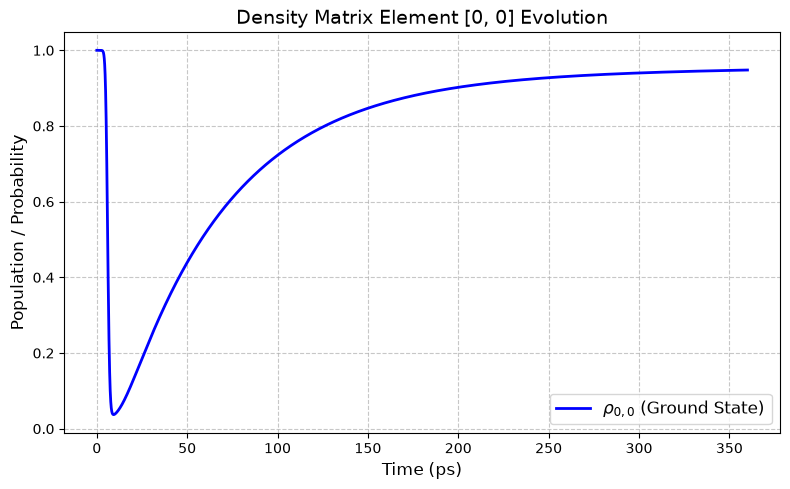

In [8]:
# 1. Extract the [0, 0] element from each density matrix in the results.
# We use .full() to convert the QuTiP Qobj into a standard NumPy array,
# and .real because diagonal density matrix elements are real populations.
rho_00_list = [rho.full()[0, 0].real for rho in result.states]

# 2. Convert your time list back to picoseconds for a readable x-axis
t_ps = tlist_sec * 1e12

# 3. Plot the data
plt.figure(figsize=(8, 5))
plt.plot(t_ps, rho_00_list, color='blue', linewidth=2, label=r'$\rho_{0,0}$ (Ground State)')

# Formatting the plot
plt.title('Density Matrix Element [0, 0] Evolution', fontsize=14)
plt.xlabel('Time (ps)', fontsize=12)
plt.ylabel('Population / Probability', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

In [2]:
#test